# agentv15_streaming — Streaming Graph Updates and LLM Tokens

This version introduces streaming.

Graph:

```text
START → planner → writer → reviewer → END
```

We will test graph update streaming, graph value streaming, and LLM token streaming.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state using NotRequired


In [3]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    plan: NotRequired[str]
    draft: NotRequired[str]
    review: NotRequired[str]
    final_answer: NotRequired[str]


## 4. Define graph nodes


In [4]:
from langchain_openai import ChatOpenAI

def planner_node(state: AgentState) -> AgentState:
    return {
        "plan": (
            "Plan: identify audience, summarize incident status, explain likely impact, "
            "and provide next action."
        )
    }

def writer_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
Write a concise incident update.

User request:
{state["input"]}

Plan:
{state["plan"]}
'''

    response = llm.invoke(prompt)
    return {"draft": response.content}

def reviewer_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
Review this incident update for clarity and actionability.

Draft:
{state["draft"]}

Return a short review and then provide the final improved version.
'''

    response = llm.invoke(prompt)

    return {
        "review": "Reviewed for clarity and actionability.",
        "final_answer": response.content,
    }


## 5. Build graph


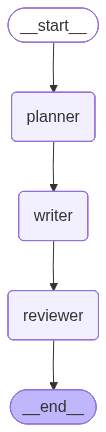

In [5]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("writer", writer_node)
    graph_builder.add_node("reviewer", reviewer_node)

    graph_builder.add_edge(START, "planner")
    graph_builder.add_edge("planner", "writer")
    graph_builder.add_edge("writer", "reviewer")
    graph_builder.add_edge("reviewer", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 6. Visualize Mermaid graph


In [6]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	writer(writer)
	reviewer(reviewer)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	planner --> writer;
	writer --> reviewer;
	reviewer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 7. Visualize PNG graph


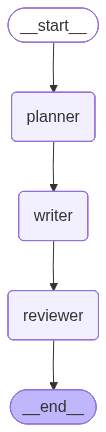

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 8. Normal invoke


In [8]:
result = graph.invoke({
    "input": "Write a short incident update for EPP CHECK-DOMAIN latency."
})

print(result["final_answer"])


**Review:**
The incident update is clear and provides essential information regarding the current status, impact, and next actions. However, it could benefit from a more structured format and additional details to enhance clarity and actionability. Specifically, including an estimated time for resolution (if available) and a contact point for urgent inquiries would improve stakeholder communication.

**Improved Version:**

---

**Incident Update: EPP CHECK-DOMAIN Latency**

**Audience:** All Stakeholders

**Status:** We are currently experiencing elevated latency with the EPP CHECK-DOMAIN service. Our engineering team is actively investigating the root cause.

**Impact:** Users may experience delays when checking domain availability, which could affect domain registration and management processes.

**Next Actions:**
- Our team is prioritizing the resolution of this issue and is working diligently to restore normal service.
- We will provide updates every hour until the situation is res

## 9. Stream graph updates


In [9]:
for chunk in graph.stream(
    {"input": "Write a short incident update for EPP CHECK-DOMAIN latency."},
    stream_mode="updates",
):
    print("\n--- update chunk ---")
    print(chunk)



--- update chunk ---
{'planner': {'plan': 'Plan: identify audience, summarize incident status, explain likely impact, and provide next action.'}}

--- update chunk ---
{'writer': {'draft': '**Incident Update: EPP CHECK-DOMAIN Latency**\n\n**Audience:** All stakeholders\n\n**Status:** We are currently experiencing elevated latency with the EPP CHECK-DOMAIN service. Our engineering team is actively investigating the root cause.\n\n**Impact:** Users may experience delays when checking domain availability, which could affect domain registration and management processes.\n\n**Next Actions:** We are working to resolve the issue as quickly as possible and will provide updates every hour until the situation is resolved. Thank you for your patience.'}}

--- update chunk ---
{'reviewer': {'review': 'Reviewed for clarity and actionability.', 'final_answer': '**Review:**\nThe incident update is clear and provides essential information regarding the current status, impact, and next actions. Howeve

## 10. Stream graph values


In [10]:
for chunk in graph.stream(
    {"input": "Write a short incident update for EPP CHECK-DOMAIN latency."},
    stream_mode="values",
):
    print("\n--- state snapshot ---")
    print(chunk)



--- state snapshot ---
{'input': 'Write a short incident update for EPP CHECK-DOMAIN latency.'}

--- state snapshot ---
{'input': 'Write a short incident update for EPP CHECK-DOMAIN latency.', 'plan': 'Plan: identify audience, summarize incident status, explain likely impact, and provide next action.'}

--- state snapshot ---
{'input': 'Write a short incident update for EPP CHECK-DOMAIN latency.', 'plan': 'Plan: identify audience, summarize incident status, explain likely impact, and provide next action.', 'draft': '**Incident Update: EPP CHECK-DOMAIN Latency**\n\n**Audience:** All stakeholders\n\n**Status:** We are currently experiencing elevated latency with the EPP CHECK-DOMAIN service. Our engineering team is actively investigating the root cause.\n\n**Impact:** Users may experience delays when checking domain availability, which could affect domain registration and management processes.\n\n**Next Actions:** We are working to resolve the issue as quickly as possible and will provi

## 11. Stream LLM tokens directly


In [11]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, streaming=True)

prompt = "Write a concise EPP incident update for CHECK-DOMAIN latency."

for token in llm.stream(prompt):
    print(token.content, end="", flush=True)


**EPP Incident Update: CHECK-DOMAIN Latency**

**Date:** [Insert Date]  
**Time:** [Insert Time]  
**Status:** Ongoing

We are currently experiencing latency issues with the CHECK-DOMAIN service. Users may notice delays in domain availability checks. Our engineering team is actively investigating the root cause and working to resolve the issue as quickly as possible.

We appreciate your patience and will provide further updates as more information becomes available. For urgent inquiries, please contact our support team.

Thank you for your understanding.

**[Your Company Name]**  
**Support Team**

## 12. Compare streaming types

LangGraph streaming:

```text
node-level progress and state updates
```

LLM token streaming:

```text
model output as it is generated
```


## 13. LangSmith trace

Open project:

```text
langgraph-playground
```

Streaming still produces traces.
